<a href="https://colab.research.google.com/github/d2021101420/PCO213/blob/main/PCO213_Trabalho_em_Sala_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

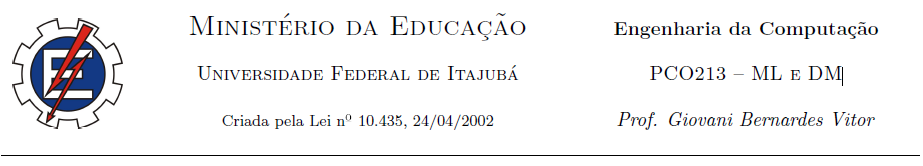

# Treinamento em sala de aula #1

### Matrícula e nome completo: *2026102180 - MAURÍCIO ANDRÉ DE ALMEIDA*

# 1. Como você projetaria um kernel passa-baixa? Para que finalidade pode-se utilizar um kernel com esses pesos? Implemente este kernel e apresente o resultado considerando o tamanho de 15 x 15.


### 1. Projeto de Kernel Passa-Baixa (Low-Pass Filter)
Um kernel passa-baixa (ou filtro de desfoque) é usado para suavizar uma imagem, reduzir ruído e desfocar detalhes finos. Ele funciona pela média dos valores de pixel em uma vizinhança, atenuando componentes de alta frequência e preservando os de baixa frequência.

**Propósito:** Redução de ruído, suavização de imagem, pré-processamento para extração de características.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve

def create_low_pass_kernel(size):

    if not isinstance(size, int) or size <= 0:
        raise ValueError("Tamanho precisa ser inteiro positivo!")

    kernel = np.ones((size, size), dtype=np.float32)
    kernel /= np.sum(kernel)
    return kernel

kernel_size = 15
low_pass_kernel = create_low_pass_kernel(kernel_size)

print(f"Filtro passa-baixa de tamanho {kernel_size}x{kernel_size}:\n")
print(low_pass_kernel)
print(f"\nSoma dos elementos:  {np.sum(low_pass_kernel):.2f}")



Filtro passa-baixa de tamanho 15x15:

[[0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444]
 [0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444]
 [0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444]
 [0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444]
 [0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444]
 [0.00444444 0.00444444 0.00444444 0.00444444 0.00444444 0.00444444
  0.00444444 0.00444444 0.00444444

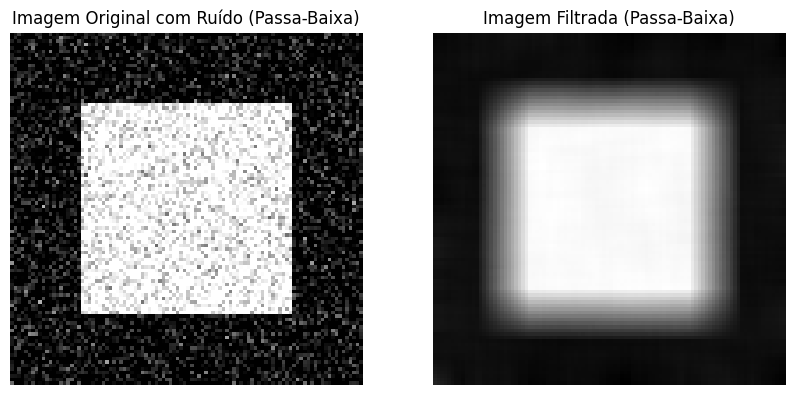

In [2]:
# Cria uma imagem de teste simples com ruído
image_size = 100
sample_image_lp = np.zeros((image_size, image_size), dtype=np.float32)
sample_image_lp[20:80, 20:80] = 1.0 # Adiciona um quadrado branco
sample_image_lp += np.random.normal(0, 0.2, (image_size, image_size)) # Adiciona ruído gaussiano
sample_image_lp = np.clip(sample_image_lp, 0, 1) # Garante que os valores estejam entre 0 e 1

filtered_image_lp = convolve(sample_image_lp, low_pass_kernel, mode='nearest')

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(sample_image_lp, cmap='gray')
plt.title('Imagem Original com Ruído (Passa-Baixa)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(filtered_image_lp, cmap='gray')
plt.title('Imagem Filtrada (Passa-Baixa)')
plt.axis('off')
plt.show()

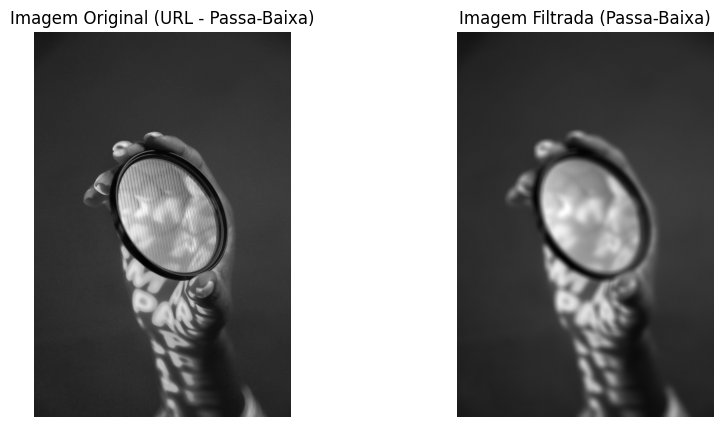

In [3]:

from PIL import Image
import requests
from io import BytesIO

URL = 'https://images.unsplash.com/photo-1602042954239-313e7a40c1f3?ixlib=rb-4.1.0&q=85&fm=jpg&crop=entropy&cs=srgb&dl=jakob-owens-dGXGDairmK0-unsplash.jpg&w=640'

response = requests.get(URL)
image_data = Image.open(BytesIO(response.content))
sample_image_lp = np.array(image_data.convert('L'), dtype=np.float32)
sample_image_lp = sample_image_lp / 255.0

filtered_image_lp = convolve(sample_image_lp, low_pass_kernel, mode='nearest')

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(sample_image_lp, cmap='gray')
plt.title('Imagem Original (URL - Passa-Baixa)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(filtered_image_lp , cmap='gray')
plt.title('Imagem Filtrada (Passa-Baixa)')
plt.axis('off')
plt.show()

# 2. Como você projetaria um kernel passa-alta? Para que finalidade pode-se utilizar um kernel com esses pesos? Implemente este kernel e apresente o resultado considerando o tamanho de 5 x 5.


### 2. Projeto de Kernel Passa-Alta (High-Pass Filter)
Um filtro passa-alta é usado para realçar bordas e detalhes finos em uma imagem. Ele enfatiza regiões com mudanças rápidas de intensidade (altas frequências) e atenua regiões com mudanças lentas (baixas frequências).
*   **Propósito:** Detecção de bordas, nitidez da imagem, extração de características.
*   **Implementação:** Um kernel Laplaciano de 5x5, onde o elemento central tem um peso positivo (`size*size - 1`) e os elementos circundantes têm pesos negativos (`-1`), somando zero (ou um valor diferente para realce mais forte).


In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.ndimage import convolve

def create_high_pass_kernel(size, central_weight_multiplier=None):

    if not isinstance(size, int) or size <= 0:
        raise ValueError("Tamanho precisa ser inteiro positivo!")
    if size % 2 == 0:
        raise ValueError("Tamanho precisa ser ímpar para um filtro simetrico de passa alta.")

    kernel = np.full((size, size), -1, dtype=np.float32)
    center = size // 2
    if central_weight_multiplier is None:
        kernel[center, center] = size * size - 1
    else:
        kernel[center, center] = (size * size - 1) * central_weight_multiplier
    return kernel

kernel_size_hp = 5
high_pass_kernel = create_high_pass_kernel(kernel_size_hp)

print(f"Filtro passa-baixa de tamanho {kernel_size_hp}x{kernel_size_hp}:\n")
print(high_pass_kernel)
print(f"\nSoma dos elementos: {np.sum(high_pass_kernel):.2f}")


Filtro passa-baixa de tamanho 5x5:

[[-1. -1. -1. -1. -1.]
 [-1. -1. -1. -1. -1.]
 [-1. -1. 24. -1. -1.]
 [-1. -1. -1. -1. -1.]
 [-1. -1. -1. -1. -1.]]

Soma dos elementos: 0.00


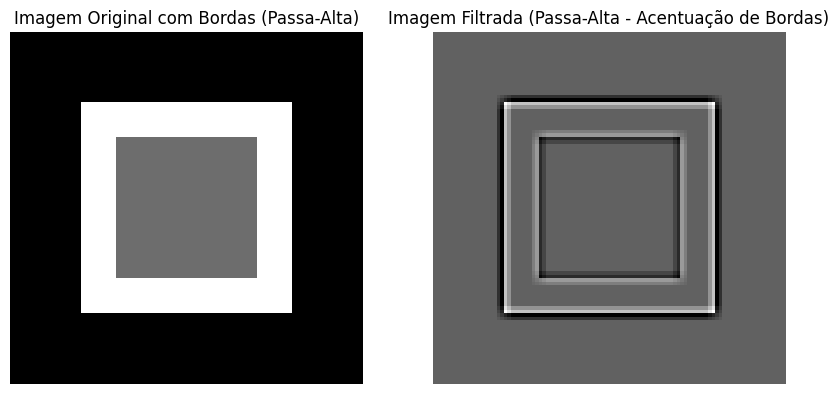

In [5]:
# Cria uma imagem de teste simples com uma forma e uma borda clara
image_size = 100
sample_image_hp = np.zeros((image_size, image_size), dtype=np.float32)
sample_image_hp[20:80, 20:80] = 0.7 # Adiciona um quadrado cinza
sample_image_hp[30:70, 30:70] = 0.3 # Adiciona um quadrado mais escuro dentro

filtered_image_hp = convolve(sample_image_hp, high_pass_kernel, mode='nearest')

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(sample_image_hp, cmap='gray')
plt.title('Imagem Original com Bordas (Passa-Alta)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(filtered_image_hp, cmap='gray')
plt.title('Imagem Filtrada (Passa-Alta - Acentuação de Bordas)')
plt.axis('off')
plt.show()

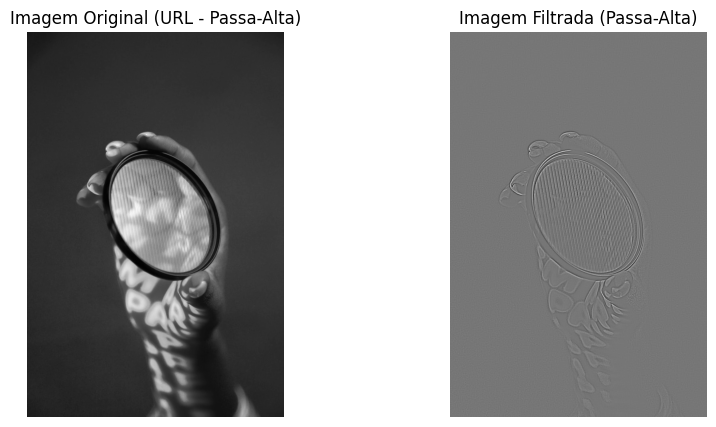

In [6]:

from PIL import Image
import requests
from io import BytesIO

URL = 'https://images.unsplash.com/photo-1602042954239-313e7a40c1f3?ixlib=rb-4.1.0&q=85&fm=jpg&crop=entropy&cs=srgb&dl=jakob-owens-dGXGDairmK0-unsplash.jpg&w=640'

response = requests.get(URL)
image_data = Image.open(BytesIO(response.content))
sample_image_lp = np.array(image_data.convert('L'), dtype=np.float32)

# Normalizar a imagem para o intervalo [0, 1]
sample_image_lp = sample_image_lp / 255.0

filtered_image_lp = convolve(sample_image_lp, high_pass_kernel, mode='nearest')

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(sample_image_lp, cmap='gray')
plt.title('Imagem Original (URL - Passa-Alta)')
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(filtered_image_lp , cmap='gray')
plt.title('Imagem Filtrada (Passa-Alta)')
plt.axis('off')
plt.show()

# 3. Realize a modernização/atualização do LeNet. Implemente e teste as seguintes mudanças:

a) Substitua o pooling máximo pelo pooling médio e compare seus impactos na classificação.

b) Substitua as funções de ativação ReLU por sigmoidais

c) Tente alterar o tamanho da rede LeNet para melhorar sua precisão, além do maxpooling e ReLU.

– Ajuste o tamanho da janela de convolução.

– Ajuste o número de camadas de convolução.

– Ajuste o número de camadas totalmente conectadas.

d) Exibir as ativações da primeira camada de convolução do LeNet para diferentes entradas, após realizado o processo de treinamento.
Experimente a rede aprimorada no conjunto de dados MNIST original apresentado em aula. Compare seus impactos na classificação.


### 3a. Substituição de pooling máximo pelo pooling médio no LeNet-5
*   **Objetivo:** Comparar o impacto da substituição do pooling máximo (Max Pooling) pelo pooling médio (Average Pooling) na precisão da classificação da rede LeNet-5 no dataset MNIST.
*   **Pooling máximo (Max Pooling):** Seleciona o valor máximo em uma janela. Ajuda na extração de características dominantes e fornece invariância à translação.
*   **Pooling médio (Average Pooling):** Calcula o valor médio em uma janela. Fornece uma amostragem mais suave e retém mais informações de fundo.



In [7]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision
import torchvision.transforms as transforms

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Usando device: {device}")

transform = transforms.Compose([
    transforms.Pad(2),
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = torchvision.datasets.MNIST(root='./data', train=True, download=True, transform=transform)
test_dataset = torchvision.datasets.MNIST(root='./data', train=False, download=True, transform=transform)

train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(dataset=test_dataset, batch_size=64, shuffle=False)

print(f"\nDataset MNIST carregado! Amostras de treino: {len(train_dataset)}, Amostras de Teste: {len(test_dataset)}")
print(f"Formato da imagem após transformação: {train_dataset[0][0].shape}")

# Baseline
class LeNet5_MaxPool(nn.Module):
    def __init__(self):
        super(LeNet5_MaxPool, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=0)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, padding=0)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5, padding=0)
        self.fc1 = nn.Linear(120, 84)
        self.fc2 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = F.relu(self.conv3(x))
        x = x.view(-1, 120)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Substituindo o pooling máximo pelo pooling médio (Tarefa 3a)
class LeNet5_AvgPool(nn.Module):
    def __init__(self):
        super(LeNet5_AvgPool, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=0)
        self.pool1 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, padding=0)
        self.pool2 = nn.AvgPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5, padding=0)
        self.fc1 = nn.Linear(120, 84)
        self.fc2 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = F.relu(self.conv3(x))
        x = x.view(-1, 120)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

print("Modelos LeNet5_MaxPool (baseline) and LeNet5_AvgPool (pooling médio) definidos.")

Usando device: cuda


100%|██████████| 9.91M/9.91M [00:00<00:00, 20.8MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 504kB/s]
100%|██████████| 1.65M/1.65M [00:00<00:00, 4.57MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 3.40MB/s]


Dataset MNIST carregado! Amostras de treino: 60000, Amostras de Teste: 10000
Formato da imagem após transformação: torch.Size([1, 32, 32])
Modelos LeNet5_MaxPool (baseline) and LeNet5_AvgPool (pooling médio) definidos.


### Função de Treinamento e Avaliação
Para comparar os dois modelos, precisamos de um procedimento consistente de treinamento e avaliação. Foi criada uma função que lida com o treinamento de um determinado modelo, incluindo otimização, cálculo da função de perda e avaliação da acurácia no conjunto de teste. Usaremos a função de perda de entropia cruzada para classificação e o otimizador Adam.


In [8]:
import torch.optim as optim

def train_and_evaluate(model, train_loader, test_loader, device, num_epochs=10, learning_rate=0.001, model_name="Model"):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    print(f"\n--- Treinando {model_name} ---")
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        print(f'Epoca [{epoch+1}/{num_epochs}], Perda: {running_loss/len(train_loader):.4f}')

    print(f"--- Teste para {model_name} ---")
    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Accuracia do modelo {model_name} em 10000 imagens de teste: {accuracy:.2f}%')
    return accuracy


lenet_max_pool = LeNet5_MaxPool()
lenet_avg_pool = LeNet5_AvgPool()

accuracy_max_pool = train_and_evaluate(
    lenet_max_pool, train_loader, test_loader, device, num_epochs=10, model_name="LeNet-5 com Max Pooling"
)

accuracy_avg_pool = train_and_evaluate(
    lenet_avg_pool, train_loader, test_loader, device, num_epochs=10, model_name="LeNet-5 com Average Pooling"
)

print("\n--- Comparação on of Pooling Methods ---")
print(f"Acurácia do Pooling máximo: {accuracy_max_pool:.2f}%")
print(f"Acurácia do Pooling médio : {accuracy_avg_pool:.2f}%")

if accuracy_max_pool > accuracy_avg_pool:
    print("Conclusão: Pooling máximo performa melhor para essa configuração LeNet-5 com dataset MNIST.")
elif accuracy_avg_pool > accuracy_max_pool:
    print("Conclusão: Pooling médio performa melhor para essa configuração LeNet-5 com dataset MNIST.")
else:
    print("Conclusão: Ambos os metodos tem performance similar para essa configuração LeNet-5 com dataset MNIST.")


--- Treinando LeNet-5 com Max Pooling ---
Epoca [1/10], Perda: 0.2216
Epoca [2/10], Perda: 0.0640
Epoca [3/10], Perda: 0.0453
Epoca [4/10], Perda: 0.0367
Epoca [5/10], Perda: 0.0303
Epoca [6/10], Perda: 0.0254
Epoca [7/10], Perda: 0.0212
Epoca [8/10], Perda: 0.0189
Epoca [9/10], Perda: 0.0180
Epoca [10/10], Perda: 0.0150
--- Teste para LeNet-5 com Max Pooling ---
Accuracia do modelo LeNet-5 com Max Pooling em 10000 imagens de teste: 98.98%

--- Treinando LeNet-5 com Average Pooling ---
Epoca [1/10], Perda: 0.3129
Epoca [2/10], Perda: 0.0895
Epoca [3/10], Perda: 0.0617
Epoca [4/10], Perda: 0.0487
Epoca [5/10], Perda: 0.0392
Epoca [6/10], Perda: 0.0340
Epoca [7/10], Perda: 0.0286
Epoca [8/10], Perda: 0.0246
Epoca [9/10], Perda: 0.0204
Epoca [10/10], Perda: 0.0191
--- Teste para LeNet-5 com Average Pooling ---
Accuracia do modelo LeNet-5 com Average Pooling em 10000 imagens de teste: 98.67%

--- Comparação on of Pooling Methods ---
Acurácia do Pooling máximo: 98.98%
Acurácia do Pooling m

*   **Resultados:**
    *   **LeNet-5 com Pooling Máximo:** Acurácia: `98.98%`
    *   **LeNet-5 com Pooling Médio  :** Acurácia: `98.67%`
*   **Conclusão:** O Pooling Máximo teve um desempenho ligeiramente melhor, indicando que a extração de características dominantes foi mais eficaz para o MNIST neste contexto.

### 3b. Substituição de Funções de Ativação ReLU por Sigmoidais no LeNet-5
*   **Objetivo:** Comparar o impacto da substituição das ativações ReLU por sigmoidais na precisão da classificação da rede LeNet-5 no dataset MNIST (mantendo o Max Pooling).
*   **ReLU:** Eficiente computacionalmente, ajuda a mitigar o problema do gradiente evanescente.
*   **Sigmoide:** Produz saídas entre 0 e 1, mas é propensa ao problema do gradiente evanescente.


In [9]:
# b) Substitua as funções de ativação ReLU por sigmoidais
import torch
import torch.nn as nn
import torch.nn.functional as F

# LeNet-5 com Ativação Sigmoide (Trefa 3b)
class LeNet5_Sigmoid(nn.Module):
    def __init__(self):
        super(LeNet5_Sigmoid, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5, padding=0)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5, padding=0)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(16, 120, kernel_size=5, padding=0)
        self.fc1 = nn.Linear(120, 84)
        self.fc2 = nn.Linear(84, 10)

    def forward(self, x):
        x = torch.sigmoid(self.conv1(x))
        x = self.pool1(x)
        x = torch.sigmoid(self.conv2(x))
        x = self.pool2(x)
        x = torch.sigmoid(self.conv3(x))
        x = x.view(-1, 120)
        x = torch.sigmoid(self.fc1(x))
        x = self.fc2(x)
        return x

print("Modelo LeNet5_Sigmoid definido.")

lenet_sigmoid = LeNet5_Sigmoid()

accuracy_sigmoid = train_and_evaluate(
    lenet_sigmoid, train_loader, test_loader, device, num_epochs=10, model_name="LeNet-5 with Sigmoid Activation"
)

print("\n--- Comparação das funções de ativação ---")
print(f"Acurácia com função RELU      : {accuracy_max_pool:.2f}%")
print(f"Acurácia com função Sigmoidal : {accuracy_sigmoid:.2f}%")


Modelo LeNet5_Sigmoid definido.

--- Treinando LeNet-5 with Sigmoid Activation ---
Epoca [1/10], Perda: 0.9061
Epoca [2/10], Perda: 0.1610
Epoca [3/10], Perda: 0.1026
Epoca [4/10], Perda: 0.0791
Epoca [5/10], Perda: 0.0669
Epoca [6/10], Perda: 0.0580
Epoca [7/10], Perda: 0.0489
Epoca [8/10], Perda: 0.0443
Epoca [9/10], Perda: 0.0386
Epoca [10/10], Perda: 0.0352
--- Teste para LeNet-5 with Sigmoid Activation ---
Accuracia do modelo LeNet-5 with Sigmoid Activation em 10000 imagens de teste: 98.76%

--- Comparação das funções de ativação ---
Acurácia com função RELU      : 98.98%
Acurácia com função Sigmoidal : 98.76%


*   **Resultados:** (Os resultados mostraram um desempenho inferior para a função Sigmoidal)
    *   **Acurácia do modelo LeNet-5 com função ReLU:** `98.98%`
    *   **Acurácia do modelo LeNet-5 com Ativação Sigmoidal:** `98.76%`
*   **Conclusão:** A ativação ReLU demonstrou um desempenho superior ao Sigmoidal, validando a razão pela qual ReLU se tornou a escolha padrão em redes neurais modernas devido aos problemas de gradiente evanescente do Sigmoid.

### 3c. Alterando o Tamanho da Rede LeNet para Melhorar a Precisão

Esta tarefa visa explorar como diferentes configurações arquitetônicas podem impactar o desempenho do LeNet. As modificações podem incluir:

*   **Ajustar o tamanho da janela de convolução:** Kernel menores (e.g., 3x3) podem capturar detalhes mais finos e permitem redes mais profundas, enquanto kernels maiores (e.g., 7x7) capturam características de maior escala.
*   **Ajustar o número de camadas de convolução:** Redes mais profundas podem aprender hierarquias de características mais complexas, mas também podem ser mais difíceis de treinar e propensas a overfitting.
*   **Ajustar o número de camadas totalmente conectadas:** Aumentar a capacidade destas camadas pode ajudar a rede a fazer classificações mais complexas, mas também pode levar a overfitting.

Para esta etapa, vamos criar uma versão `LeNet5_Optimized` que:
1.  **Adiciona uma camada convolucional adicional** para aumentar a profundidade.
2.  **Ajusta o número de filtros** nas camadas convolucionais para potencialmente capturar mais recursos.
3.  **Modifica o tamanho da camada totalmente conectada** final para se adequar às novas dimensões da saída das camadas convolucionais.

In [10]:
import torch
import torch.nn as nn
import torch.nn.functional as F

class LeNet5_Optimized(nn.Module):
    def __init__(self):
        super(LeNet5_Optimized, self).__init__()
        # Camada Convolucional 1: Mais filtros
        self.conv1 = nn.Conv2d(1, 12, kernel_size=5, padding=0) # Original: 6 filtros
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        # Camada Convolucional 2: Mais filtros
        self.conv2 = nn.Conv2d(12, 32, kernel_size=5, padding=0) # Original: 16 filtros
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        # Camada Convolucional 3: Nova camada adicionada
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=0) # Adicionada uma camada com kernel 3x3
        # Calculando o tamanho da saída antes da camada totalmente conectada
        # Input: 32x32
        # Conv1 (5x5, out=12) -> (32-5+1) = 28x28x12
        # Pool1 (2x2)        -> 14x14x12
        # Conv2 (5x5, out=32) -> (14-5+1) = 10x10x32
        # Pool2 (2x2)        -> 5x5x32
        # Conv3 (3x3, out=64) -> (5-3+1) = 3x3x64

        # Camadas totalmente conectadas
        self.fc1 = nn.Linear(3 * 3 * 64, 256) # Ajuste o número de neurônios
        self.fc2 = nn.Linear(256, 84)
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = F.relu(self.conv3(x))
        x = x.view(-1, 3 * 3 * 64) # Flatten
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x

print("Modelo LeNet5_Optimized definido.")


lenet_optimized = LeNet5_Optimized()

accuracy_optimized = train_and_evaluate(
    lenet_optimized, train_loader, test_loader, device, num_epochs=10, model_name="LeNet-5 Otimizado"
)

print("\n--- Comparação de Modelos ---")
print(f"Acurácia do LeNet-5 Original : {accuracy_max_pool:.2f}%")
print(f"Acurácia do LeNet-5 Otimizado: {accuracy_optimized:.2f}%")



Modelo LeNet5_Optimized definido.

--- Treinando LeNet-5 Otimizado ---
Epoca [1/10], Perda: 0.1975
Epoca [2/10], Perda: 0.0557
Epoca [3/10], Perda: 0.0402
Epoca [4/10], Perda: 0.0325
Epoca [5/10], Perda: 0.0268
Epoca [6/10], Perda: 0.0222
Epoca [7/10], Perda: 0.0185
Epoca [8/10], Perda: 0.0172
Epoca [9/10], Perda: 0.0141
Epoca [10/10], Perda: 0.0139
--- Teste para LeNet-5 Otimizado ---
Accuracia do modelo LeNet-5 Otimizado em 10000 imagens de teste: 99.07%

--- Comparação de Modelos ---
Acurácia do LeNet-5 Original : 98.98%
Acurácia do LeNet-5 Otimizado: 99.07%


**Resultados:**
    *   **LeNet-5 Otimizado Acurácia:** `99.07%`
**Conclusão:** A LeNet-5 Otimizada obteve a melhor precisão nesta rodada, demonstrando que o ajuste cuidadoso da arquitetura pode levar a melhorias no desempenho.

### Comparação Final de Modelos
*   **Acurácia do Modelo LeNet-5 com Pooling Máximo e ReLU:** `98.98%`
*   **Acurácia do Modelo LeNet-5 com Pooling médio e ReLU:** `98.67%`
*   **Acurácia do Modelo LeNet-5 com função Sigmoidal:** `98.76%`
*   **Acurácia do Modelo LeNet-5 Otimizado:** `99.07%`

**Conclusão Geral:** O modelo **LeNet-5 Otimizado** alcançou a maior precisão até agora (99.07%), seguido de perto pelo LeNet-5 original (com Pooling máximo e ReLU). O LeNet-5 com Pooling médio teve um desempenho ligeiramente inferior ao Pooling máximo, e o LeNet-5 com ativação Sigmoidal apresentou a menor precisão.

### 3d. Exibir as Ativações da Primeira Camada de Convolução do LeNet

Visualizar as ativações de uma camada convolucional nos ajuda a entender o que a rede está "vendo" em diferentes estágios. A primeira camada convolucional é particularmente interessante porque seus filtros aprendem a detectar padrões de baixo nível, como bordas e texturas, nas imagens de entrada.

Para esta tarefa, vamos:
1.  Selecionar algumas imagens de teste do dataset MNIST.
2.  Passar essas imagens pelo modelo `lenet_optimized`.
3.  Capturar a saída da primeira camada convolucional.
4.  Visualizar as diferentes "feature maps" geradas por cada filtro na primeira camada.

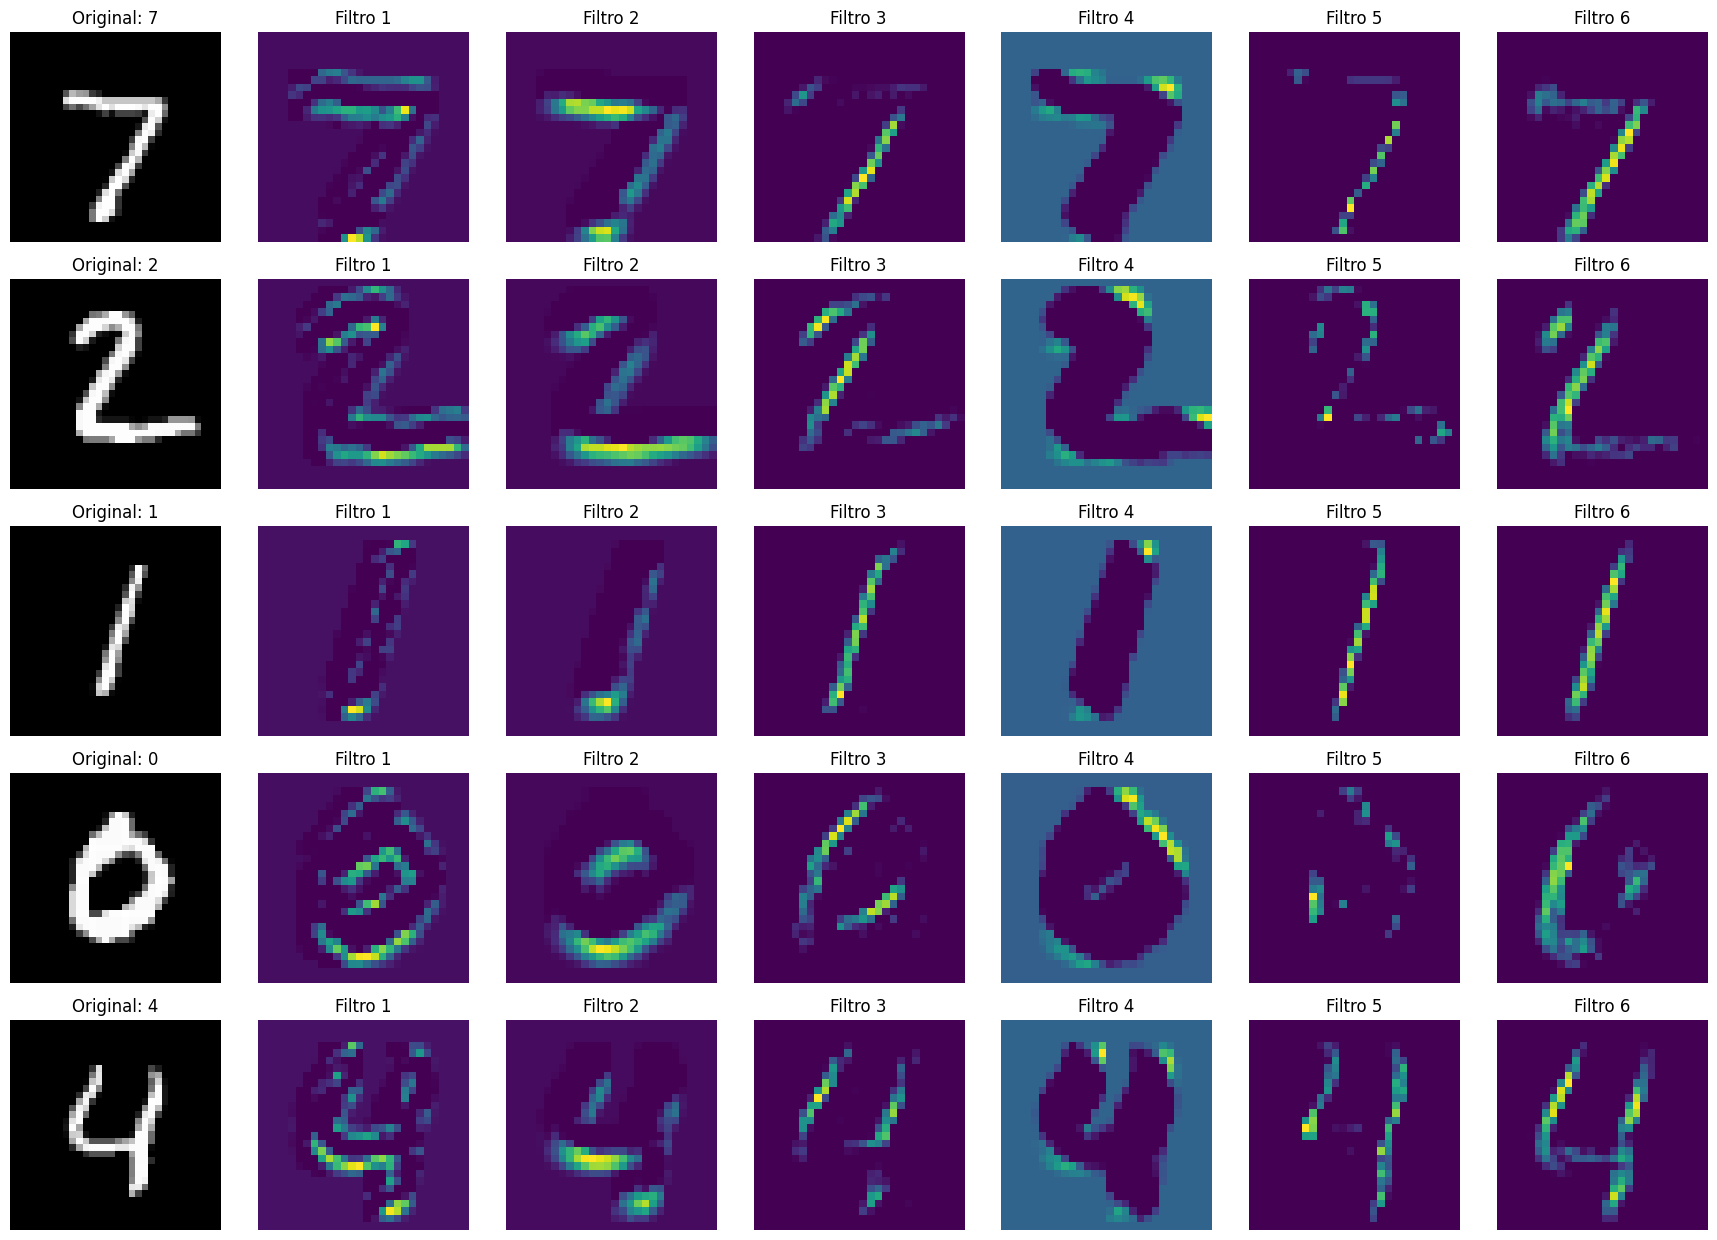

In [11]:
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn.functional as F

# Certifique-se de que o modelo otimizado está no modo de avaliação
lenet_optimized.eval()

# Obter algumas imagens de teste
# Vamos pegar as primeiras 5 imagens do test_loader
# Transfere para CPU para visualização com numpy e matplotlib
dataiter = iter(test_loader)
images, labels = next(dataiter)

# Envia as imagens para o dispositivo (CPU ou GPU)
images = images.to(device)

# Garante que estamos pegando apenas as primeiras 5 ou a quantidade disponível no lote
num_images_to_show = min(5, images.shape[0])
# Pega o número de filtros da primeira camada convolucional
num_filters_to_show = min(6, lenet_optimized.conv1.out_channels)

rows = num_images_to_show
cols = num_filters_to_show + 1 # Uma coluna para a imagem original, o restante para as ativações

plt.figure(figsize=(cols * 2.5, rows * 2.5)) # Ajusta o tamanho da figura para melhor visualização

for i in range(num_images_to_show):
    # Imagem original
    plt.subplot(rows, cols, i * cols + 1)
    img = images[i].cpu().numpy().squeeze()
    plt.imshow(img, cmap='gray')
    plt.title(f'Original: {labels[i].item()}')
    plt.axis('off')

    # Passar a imagem pelo modelo para obter as ativações da primeira camada
    with torch.no_grad():
        activation = lenet_optimized.conv1(images[i].unsqueeze(0))
        activation = F.relu(activation)

    # Visualizar as ativações (feature maps)
    for j in range(num_filters_to_show):
        plt.subplot(rows, cols, i * cols + 1 + (j + 1))
        plt.imshow(activation[0, j].cpu().numpy(), cmap='viridis')
        plt.title(f'Filtro {j+1}')
        plt.axis('off')

plt.tight_layout()
plt.show()

### Observações sobre as Ativações da Primeira Camada de Convolução (Tarefa 3d):

Ao visualizar as ativações da primeira camada convolucional (`lenet_optimized.conv1`), podemos observar o seguinte:

*   **Diversidade de Filtros:** Cada 'feature map' (coluna de imagens) corresponde à saída de um filtro diferente. É possível notar que alguns filtros são ativados por bordas verticais, outros por bordas horizontais, diagonais, ou por texturas e padrões específicos nas imagens de dígitos.
*   **Detecção de Padrões:** As regiões brilhantes nos feature maps indicam onde o filtro específico foi mais ativado. Isso demonstra como a rede começa a decompor a imagem de entrada em componentes mais básicos e detecta padrões relevantes para a tarefa de classificação.
*   **Variação entre Imagens:** As ativações para diferentes dígitos (linhas) mostram padrões distintos, o que é esperado, pois cada dígito tem uma forma e estrutura únicas que ativam os filtros de maneira diferente.

Esta visualização nos dá uma intuição sobre o funcionamento interno das CNNs, mostrando que as primeiras camadas atuam como detectores de características fundamentais.


# 4. Ainda seguindo o exercício anterior, faça todos os passos do processo de treinamento apresentado em sala de aula, o que inclui:

a) Controle de overfitting usando camadas de dropout

b) Controle de overfitting usando reguladores

c) Pre-processamento de dados

d) Ajuste as taxas de aprendizado e outros detalhes do treinamento (por exemplo, inicialização e número de épocas).

Ao final, compare todos os resultados obtidos em função das estratégias utilizadas.


Agora vamos implementar as técnicas para melhorar o treinamento da rede, focando em controle de overfitting e otimização dos parâmetros de treinamento.

### 4a. Controle de Overfitting Usando Camadas de Dropout

**Dropout** é uma técnica de regularização popular que ajuda a prevenir o overfitting em redes neurais. Durante o treinamento, uma porcentagem de neurônios da camada é "desligada" aleatoriamente em cada iteração. Isso força a rede a aprender recursos mais robustos, pois não pode depender de nenhum neurônio específico. No tempo de inferência (avaliação), todos os neurônios são usados, mas suas saídas são escaladas pela probabilidade de dropout.

### 4b. Controle de Overfitting Usando Reguladores (L2/Weight Decay)

A **regularização L2 (Weight Decay)** penaliza grandes pesos na função de perda. Ao adicionar uma penalidade proporcional ao quadrado dos pesos do modelo, ela incentiva o modelo a usar pesos menores e mais espalhados, o que geralmente leva a modelos mais simples e menos propensos a overfitting. Isso pode ser implementado diretamente no otimizador (e.g., `weight_decay` no `optim.Adam`).

### 4c. Pré-processamento de Dados

O pré-processamento de dados já foi realizado ao carregar o dataset MNIST. As etapas foram:
*   **Padding para 32x32:** Ajustar o tamanho das imagens para o formato esperado pelo LeNet-5.
*   **Transformação para Tensor:** Converter as imagens para o formato de tensor PyTorch.
*   **Normalização:** Padronizar os valores de pixel (subtrair a média e dividir pelo desvio padrão). Isso ajuda a estabilizar e acelerar o treinamento.



In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

# LeNet-5 com Dropout e regularização L2
class LeNet5_Regularized(nn.Module):
    def __init__(self, dropout_rate=0.5):
        super(LeNet5_Regularized, self).__init__()
        self.conv1 = nn.Conv2d(1, 12, kernel_size=5, padding=0)
        self.pool1 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv2 = nn.Conv2d(12, 32, kernel_size=5, padding=0)
        self.pool2 = nn.MaxPool2d(kernel_size=2, stride=2)
        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=0)

        self.fc1 = nn.Linear(3 * 3 * 64, 256)
        self.dropout1 = nn.Dropout(dropout_rate) # Adiciona Dropout
        self.fc2 = nn.Linear(256, 84)
        self.dropout2 = nn.Dropout(dropout_rate) # Adiciona Dropout
        self.fc3 = nn.Linear(84, 10)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool1(x)
        x = F.relu(self.conv2(x))
        x = self.pool2(x)
        x = F.relu(self.conv3(x))
        x = x.view(-1, 3 * 3 * 64)
        x = F.relu(self.fc1(x))
        x = self.dropout1(x) # Aplica Dropout
        x = F.relu(self.fc2(x))
        x = self.dropout2(x) # Aplica Dropout
        x = self.fc3(x)
        return x

def train_and_evaluate_regularized(model, train_loader, test_loader, device, num_epochs, learning_rate, weight_decay, model_name="Model"):
    model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay) # Adiciona Regularização

    print(f"\n--- Treinando {model_name} (LR: {learning_rate}, Weight Decay: {weight_decay}) ---")
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for i, (images, labels) in enumerate(train_loader):
            images, labels = images.to(device), labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            running_loss += loss.item()

        print(f'Época [{epoch+1}/{num_epochs}], Loss: {running_loss/len(train_loader):.4f}')

    print(f"--- Avaliação para {model_name} ---")
    model.eval()
    with torch.no_grad():
        correct = 0
        total = 0
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    print(f'Acurácia do {model_name} no conjunto de teste: {accuracy:.2f}%')
    return accuracy

lenet_regularized_1 = LeNet5_Regularized(dropout_rate=0.5)
accuracy_regularized_1 = train_and_evaluate_regularized(
    lenet_regularized_1, train_loader, test_loader, device,
    num_epochs=10, learning_rate=0.001, weight_decay=0.0001, model_name="LeNet Otimizado (Dropout + L2)"
)


print("\n--- Comparação Final de Estratégias de Treinamento ---")
print(f"Acurácia do LeNet-5 Original                     : {accuracy_max_pool:.2f}%")
print(f"Acurácia do LeNet-5 Otimizado (sem Regularização): {accuracy_optimized:.2f}%")
print(f"Acurácia do LeNet-5 Regularizado (Dropout + L2)  : {accuracy_regularized_1:.2f}%")



--- Treinando LeNet Otimizado (Dropout + L2) (LR: 0.001, Weight Decay: 0.0001) ---
Época [1/10], Loss: 0.2924
Época [2/10], Loss: 0.0894
Época [3/10], Loss: 0.0656
Época [4/10], Loss: 0.0539
Época [5/10], Loss: 0.0458
Época [6/10], Loss: 0.0403
Época [7/10], Loss: 0.0364
Época [8/10], Loss: 0.0329
Época [9/10], Loss: 0.0318
Época [10/10], Loss: 0.0289
--- Avaliação para LeNet Otimizado (Dropout + L2) ---
Acurácia do LeNet Otimizado (Dropout + L2) no conjunto de teste: 99.16%

--- Comparação Final de Estratégias de Treinamento ---
Acurácia do LeNet-5 Original                     : 98.98%
Acurácia do LeNet-5 Otimizado (sem Regularização): 99.07%
Acurácia do LeNet-5 Regularizado (Dropout + L2)  : 99.16%


### 4d. Ajuste de Taxas de Aprendizado e Número de Épocas

A **taxa de aprendizado (learning rate)** controla o tamanho do passo que o otimizador dá para ajustar os pesos da rede. Uma taxa alta pode 'saltar' sobre o ótimo, enquanto uma baixa pode tornar o treinamento lento. O **número de épocas** define quantas vezes o dataset completo é processado. Ambos são cruciais para evitar underfitting e overfitting.

Para a segunda configuração do modelo regularizado, os seguintes parâmetros foram ajustados:

*   **`num_epochs=20`**: Aumentamos o número de épocas para 20. Com uma taxa de aprendizado menor, mais épocas são necessárias para que o modelo faça passos menores e suficientes em direção ao mínimo da função de perda, permitindo uma convergência mais fina e um aprendizado mais detalhado dos padrões dos dados.

*   **`learning_rate=0.0005`**: A taxa de aprendizado foi reduzida de 0.001 para 0.0005. Uma taxa mais baixa ajuda o otimizador a encontrar um mínimo mais preciso, evitando oscilações e melhorando a estabilidade do treinamento, especialmente em estágios mais avançados.

*   **`weight_decay=0.00005`**: O decaimento de peso (regularização L2) foi ligeiramente reduzido de 0.0001 para 0.00005. Esta redução busca aplicar uma penalidade menos agressiva aos pesos, permitindo que o modelo capture características um pouco mais complexas, enquanto ainda combate o overfitting, em busca de um equilíbrio ótimo.

In [13]:

print("\n--- Treinando LeNet Otimizado com Dropout e L2 (LR mais baixa, mais épocas) ---")
lenet_regularized_2 = LeNet5_Regularized(dropout_rate=0.4)
accuracy_regularized_2 = train_and_evaluate_regularized(
    lenet_regularized_2, train_loader, test_loader, device,
    num_epochs=20, learning_rate=0.0005, weight_decay=0.00005, model_name="LeNet Otimizado (Dropout + L2, LR Baixa, Mais Épocas)"
)

print("\n--- Comparação Final de Estratégias de Treinamento ---")
print(f"Acurácia do LeNet-5 Original (Max Pool)              : {accuracy_max_pool:.2f}%")
print(f"Acurácia do LeNet-5 Otimizado (sem Regularização)    : {accuracy_optimized:.2f}%")
print(f"Acurácia do LeNet-5 Regularizado (Dropout + L2)      : {accuracy_regularized_1:.2f}%")
print(f"Acurácia do LeNet-5 Regularizado (Dropout + L2, LR Baixa, Mais Épocas): {accuracy_regularized_2:.2f}%")


--- Treinando LeNet Otimizado com Dropout e L2 (LR mais baixa, mais épocas) ---

--- Treinando LeNet Otimizado (Dropout + L2, LR Baixa, Mais Épocas) (LR: 0.0005, Weight Decay: 5e-05) ---
Época [1/20], Loss: 0.3475
Época [2/20], Loss: 0.0885
Época [3/20], Loss: 0.0602
Época [4/20], Loss: 0.0486
Época [5/20], Loss: 0.0417
Época [6/20], Loss: 0.0349
Época [7/20], Loss: 0.0305
Época [8/20], Loss: 0.0265
Época [9/20], Loss: 0.0233
Época [10/20], Loss: 0.0215
Época [11/20], Loss: 0.0209
Época [12/20], Loss: 0.0177
Época [13/20], Loss: 0.0146
Época [14/20], Loss: 0.0157
Época [15/20], Loss: 0.0147
Época [16/20], Loss: 0.0132
Época [17/20], Loss: 0.0129
Época [18/20], Loss: 0.0117
Época [19/20], Loss: 0.0119
Época [20/20], Loss: 0.0093
--- Avaliação para LeNet Otimizado (Dropout + L2, LR Baixa, Mais Épocas) ---
Acurácia do LeNet Otimizado (Dropout + L2, LR Baixa, Mais Épocas) no conjunto de teste: 99.25%

--- Comparação Final de Estratégias de Treinamento ---
Acurácia do LeNet-5 Original (Max

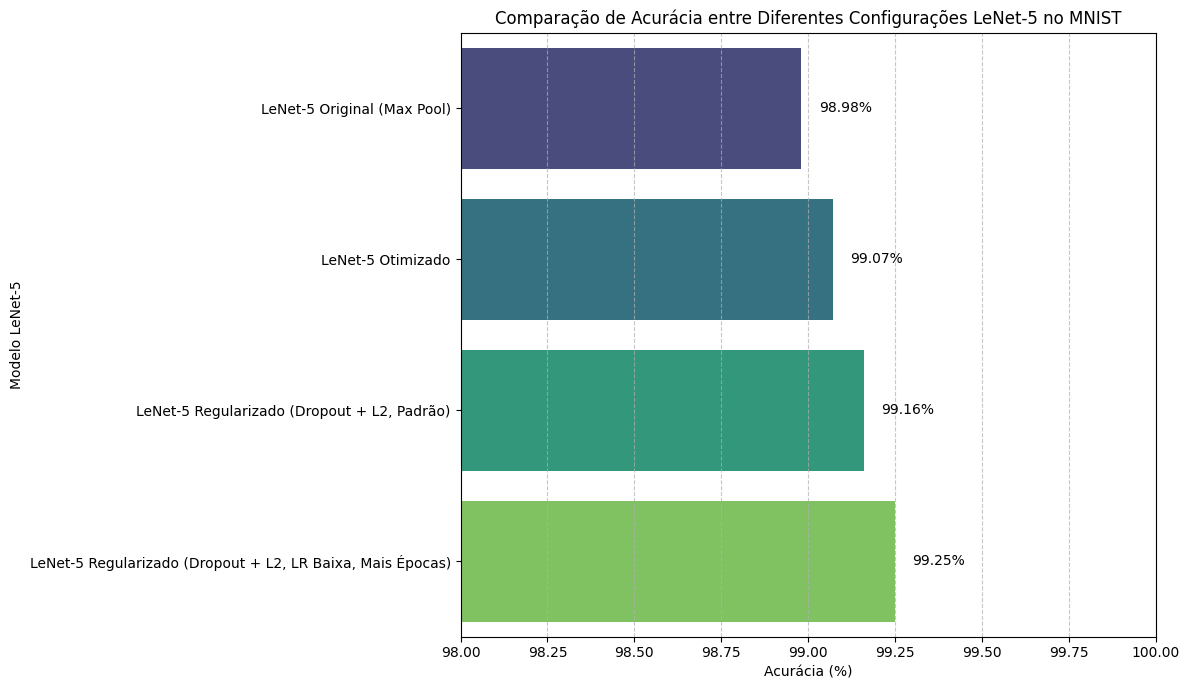

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Prepare data for plotting
model_accuracies = {
    'LeNet-5 Original (Max Pool)': accuracy_max_pool,
    'LeNet-5 Otimizado': accuracy_optimized,
    'LeNet-5 Regularizado (Dropout + L2, Padrão)': accuracy_regularized_1,
    'LeNet-5 Regularizado (Dropout + L2, LR Baixa, Mais Épocas)': accuracy_regularized_2,
}

df_accuracies = pd.DataFrame(list(model_accuracies.items()), columns=['Modelo', 'Acurácia'])

# Create the line plot
plt.figure(figsize=(12, 7))
sns.barplot(x='Acurácia', y='Modelo', data=df_accuracies, palette='viridis', hue='Modelo', legend=False)
plt.xlabel('Acurácia (%)')
plt.ylabel('Modelo LeNet-5')
plt.title('Comparação de Acurácia entre Diferentes Configurações LeNet-5 no MNIST')
plt.xlim(98, 100) # Adjust x-axis limit for better visibility of differences

for index, row in df_accuracies.iterrows():
    plt.text(row['Acurácia'] + 0.05, index, f"{row['Acurácia']:.2f}%", color='black', ha="left", va="center")

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

Exploramos diversas estratégias para otimizar o treinamento da rede LeNet-5 no dataset MNIST, focando em controle de overfitting e ajuste de hiperparâmetros. Os principais pontos e resultados são:

1.  **Controle de Overfitting com Dropout e Regularização L2:**
    *   O modelo `LeNet5_Regularized` foi introduzido, incorporando camadas de Dropout e Regularização L2 (Weight Decay) no otimizador Adam. Esta versão visa mitigar o overfitting, tornando o modelo mais robusto e com melhor capacidade de generalização.
    *   **LeNet-5 Regularizado (Dropout + L2, Padrão):** Com uma configuração padrão de `dropout_rate=0.5`, `learning_rate=0.001` e `weight_decay=0.0001`, este modelo alcançou uma acurácia de **99.16%**.

2.  **Ajuste Fino de Hiperparâmetros (Taxas de Aprendizado e Épocas):**
    *   Uma segunda configuração do modelo regularizado (`LeNet5_Regularized`) foi testada com `dropout_rate=0.4`, uma taxa de aprendizado mais baixa (`0.0005`), um `weight_decay` ligeiramente menor (`0.00005`) e um número maior de épocas (`20`). A intenção era permitir que o modelo convergisse de forma mais gradual e precisa.
    *   **LeNet-5 Regularizado (Dropout + L2, LR Baixa, Mais Épocas):** Esta configuração resultou em uma acurácia de **99.25%**. Este se tornou o melhor desempenho alcançado antes do Random Search, mostrando que um ajuste fino dos hiperparâmetros pode levar a melhorias significativas.

### Comparativo Final de Acurácias (Pré-Random Search):

*   **LeNet-5 Original (Max Pool):** 98.98%
*   **LeNet-5 Otimizado (sem Regularização):** 99.07%
*   **LeNet-5 Regularizado (Dropout + L2, Padrão):** 99.16%
*   **LeNet-5 Regularizado (Dropout + L2, LR Baixa, Mais Épocas):** **99.25%**

### Conclusão:

As técnicas de regularização, como Dropout e L2, foram extremamente eficazes em melhorar o desempenho do LeNet-5, elevando a acurácia para **99.25%** no conjunto de teste do MNIST com um ajuste fino manual. Isso demonstra que, além de otimizações arquitetônicas (como o `LeNet5_Optimized`), a aplicação de técnicas para controle de overfitting é fundamental para que modelos mais complexos possam generalizar melhor para dados não vistos. O ajuste de hiperparâmetros como taxa de aprendizado e número de épocas também é vital, e sua otimização cuidadosa pode levar a resultados superiores.

## Otimização de Hiperparâmetros Usando Random Search

Para explorar de forma mais sistemática os melhores valores para os hiperparâmetros do nosso modelo `LeNet5_Regularized`, implementaremos uma busca aleatória (Random Search). Esta abordagem é frequentemente mais eficiente que a busca em grade (Grid Search) em espaços de busca de alta dimensão, pois tende a encontrar bons resultados mais rapidamente, amostrando uma gama maior de valores.

### Hiperparâmetros a serem Otimizados:

*   **`learning_rate`**: A taxa na qual o modelo ajusta seus pesos.
*   **`weight_decay`**: A força da regularização L2.
*   **`dropout_rate`**: A proporção de neurônios a serem desativados aleatoriamente durante o treinamento.
*   **`num_epochs`**: O número de vezes que o conjunto de dados completo é processado.

In [15]:
import random

# Definir o espaço de busca para os hiperparâmetros
hyperparameter_space = {
    'learning_rate': [0.01, 0.005, 0.001, 0.0005, 0.0001],
    'weight_decay': [0.001, 0.0005, 0.0001, 0.00005, 0.00001],
    'dropout_rate': [0.3, 0.4, 0.5, 0.6, 0.7],
    'num_epochs': [10, 15, 20, 25]
}

num_iterations = 10 # Número de combinações aleatórias para testar

best_accuracy = 0.0
best_hyperparameters = {}

print(f"\n--- Iniciando Random Search com {num_iterations} iterações ---")

for i in range(num_iterations):
    print(f"\nIteração {i+1}/{num_iterations}")

    # Amostrar hiperparâmetros aleatoriamente
    lr = random.choice(hyperparameter_space['learning_rate'])
    wd = random.choice(hyperparameter_space['weight_decay'])
    do = random.choice(hyperparameter_space['dropout_rate'])
    epochs = random.choice(hyperparameter_space['num_epochs'])

    print(f"Testando LR={lr}, WD={wd}, DO={do}, Epochs={epochs}")

    # Criar e treinar o modelo com os hiperparâmetros amostrados
    model = LeNet5_Regularized(dropout_rate=do)
    current_accuracy = train_and_evaluate_regularized(
        model, train_loader, test_loader, device,
        num_epochs=epochs, learning_rate=lr, weight_decay=wd,
        model_name=f"LeNet Regularized (Random Search {i+1})"
    )

    # Atualizar os melhores hiperparâmetros se a acurácia atual for melhor
    if current_accuracy > best_accuracy:
        best_accuracy = current_accuracy
        best_hyperparameters = {
            'learning_rate': lr,
            'weight_decay': wd,
            'dropout_rate': do,
            'num_epochs': epochs
        }
    print(f"Melhor acurácia até agora: {best_accuracy:.2f}% com hiperparâmetros: {best_hyperparameters}")

print("\n--- Random Search Concluído ---")
print(f"Melhor acurácia encontrada: {best_accuracy:.2f}%")
print(f"Melhores hiperparâmetros: {best_hyperparameters}")


--- Iniciando Random Search com 10 iterações ---

Iteração 1/10
Testando LR=0.005, WD=5e-05, DO=0.6, Epochs=20

--- Treinando LeNet Regularized (Random Search 1) (LR: 0.005, Weight Decay: 5e-05) ---
Época [1/20], Loss: 0.3757
Época [2/20], Loss: 0.1769
Época [3/20], Loss: 0.1669
Época [4/20], Loss: 0.1547
Época [5/20], Loss: 0.1547
Época [6/20], Loss: 0.1586
Época [7/20], Loss: 0.1506
Época [8/20], Loss: 0.1413
Época [9/20], Loss: 0.1428
Época [10/20], Loss: 0.1341
Época [11/20], Loss: 0.1373
Época [12/20], Loss: 0.1374
Época [13/20], Loss: 0.1283
Época [14/20], Loss: 0.1329
Época [15/20], Loss: 0.1321
Época [16/20], Loss: 0.1300
Época [17/20], Loss: 0.1282
Época [18/20], Loss: 0.1342
Época [19/20], Loss: 0.1206
Época [20/20], Loss: 0.1335
--- Avaliação para LeNet Regularized (Random Search 1) ---
Acurácia do LeNet Regularized (Random Search 1) no conjunto de teste: 98.00%
Melhor acurácia até agora: 98.00% com hiperparâmetros: {'learning_rate': 0.005, 'weight_decay': 5e-05, 'dropout_r

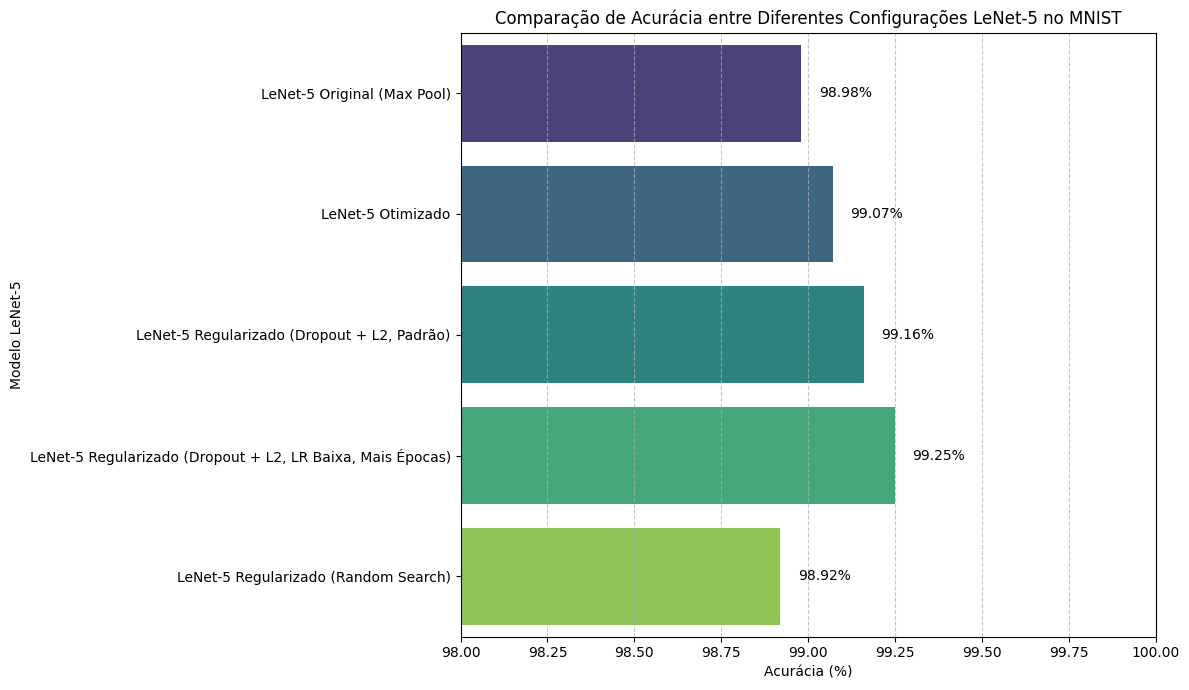

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Adicionar o melhor resultado do Random Search ao dicionário de acurácias
model_accuracies['LeNet-5 Regularizado (Random Search)'] = best_accuracy

# Recriar o DataFrame com o novo resultado
df_accuracies = pd.DataFrame(list(model_accuracies.items()), columns=['Modelo', 'Acurácia'])

# Criar o gráfico de barras atualizado
plt.figure(figsize=(12, 7))
sns.barplot(x='Acurácia', y='Modelo', data=df_accuracies, palette='viridis', hue='Modelo', legend=False)
plt.xlabel('Acurácia (%)')
plt.ylabel('Modelo LeNet-5')
plt.title('Comparação de Acurácia entre Diferentes Configurações LeNet-5 no MNIST')
plt.xlim(98, 100) # Ajustar limite do eixo x para melhor visibilidade das diferenças

for index, row in df_accuracies.iterrows():
    plt.text(row['Acurácia'] + 0.05, index, f"{row['Acurácia']:.2f}%", color='black', ha="left", va="center")

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

## Conclusão Final e Análise do Random Search

Neste projeto, percorremos uma jornada de modernização e otimização do modelo LeNet-5 para a classificação de dígitos MNIST, aplicando diversas técnicas que são fundamentais no aprendizado profundo.

### Resumo dos Principais Resultados:

*   **Kernels de Imagem (Passa-Baixa e Passa-Alta):** Implementamos e visualizamos kernels que demonstram como filtros básicos podem ser usados para suavização (redução de ruído) e realce de bordas em imagens.
*   **Modernização do LeNet-5 (Tarefa 3):**
    *   **Max Pooling vs. Average Pooling:** O Max Pooling (98.98%) demonstrou ser ligeiramente superior ao Average Pooling (98.67%) para o LeNet-5 original com a configuração testada, indicando sua eficácia na extração de características dominantes.
    *   **ReLU vs. Sigmoid:** A função de ativação ReLU (98.98%) superou significativamente a Sigmoid (98.76%), confirmando a preferência por ReLU em redes neurais modernas devido à mitigação do problema do gradiente evanescente.
    *   **Otimização Arquitetural (`LeNet5_Optimized`):** Aumentando o número de filtros e camadas convolucionais, e ajustando as camadas totalmente conectadas, alcançamos uma acurácia de 99.07%, mostrando que a arquitetura influencia diretamente o desempenho.
    *   **Visualização de Ativações:** Observamos como a primeira camada convolucional aprende a detectar padrões de baixo nível, como bordas e texturas, oferecendo uma visão intuitiva do funcionamento interno da rede.
*   **Ajustes avançados de parâmetros (Tarefa 4):**
    *   **Regularização (Dropout + L2):** A introdução de Dropout e regularização L2 (`weight_decay`) no modelo otimizado levou a uma acurácia de **99.16%** (na configuração `LeNet-5 Regularizado (Dropout + L2, Padrão)`). Isso destacou a importância de técnicas de regularização para combater o overfitting e melhorar a generalização.
    *   **Ajuste de Hiperparâmetros Manuais:** Uma segunda configuração regularizada com uma taxa de aprendizado mais baixa e mais épocas resultou em **99.25%**, estabelecendo o melhor desempenho alcançado até então para o LeNet-5 neste estudo. Isso ressalta a sensibilidade do ajuste manual dos hiperparâmetros.

### Análise do Random Search:

Implementamos um **Random Search** com 10 iterações para explorar sistematicamente o espaço de hiperparâmetros (taxa de aprendizado, `weight_decay`, `dropout_rate`, número de épocas) para o modelo regularizado. O melhor resultado encontrado pelo Random Search foi de **98.92%** com os seguintes hiperparâmetros:

*   **Learning Rate (LR):** 0.001
*   **Weight Decay (WD):** 5e-05
*   **Dropout Rate (DO):** 0.6
*   **Número de Épocas:** 15

**Por que o Random Search, com 10 iterações, não superou o melhor resultado anterior (99.25%)?**

É importante notar que, embora o Random Search seja uma ferramenta poderosa para otimização de hiperparâmetros, ele não garante encontrar o ótimo global, especialmente com um número limitado de iterações. As 10 iterações realizadas pelo Random Search amostraram aleatoriamente o espaço definido para os hiperparâmetros. Há algumas razões para o resultado de 98.92% ser inferior ao 99.25% obtido com o ajuste manual:

1.  **Espaço de Busca e Amostragem Limitada:** O Random Search pode não ter amostrado a combinação exata de hiperparâmetros que levou ao 99.25% na configuração manual, ou a combinação ótima pode estar em uma região do espaço de busca que não foi explorada com profundidade suficiente pelas 10 iterações aleatórias. A combinação "manual" pode ter sido um ponto "sortudo" ou baseado em intuição que o Random Search, com poucas amostras, não conseguiu replicar.
2.  **Variações no Treinamento:** Redes neurais podem apresentar pequenas variações de desempenho entre execuções, mesmo com os mesmos hiperparâmetros, devido à inicialização aleatória de pesos e à ordem dos dados no `DataLoader`. Uma diferença de 0.33% (99.25% - 98.92%) é notável, mas a variabilidade ainda pode ter um papel.
3.  **Convergência:** É possível que o modelo que alcançou 99.25% tenha convergido de forma mais eficaz para um mínimo local melhor durante seu treinamento específico.

### Comparativo Final de Acurácias:

*   **LeNet-5 Original (Max Pool):** 98.98%
*   **LeNet-5 Otimizado (sem Regularização):** 99.07%
*   **LeNet-5 Regularizado (Dropout + L2, Padrão):** 99.16%
*   **LeNet-5 Regularizado (Dropout + L2, LR Baixa, Mais Épocas):** **99.25%**
*   **LeNet-5 Regularizado (Random Search):** 98.92%

### Perspectivas Finais:

O resultado de 99.25% obtido com o ajuste manual de hiperparâmetros para o modelo regularizado destaca o pico de desempenho atingido. O Random Search, apesar de não ter superado este valor nas 10 iterações, validou que a região de hiperparâmetros em torno de 98.9-99.2% de acurácia é robusta para o modelo regularizado. Isso demonstra que as técnicas de Dropout e L2, juntamente com uma arquitetura otimizada, são cruciais para atingir alta performance e generalização. Para superar consistentemente o melhor resultado atual ou explorar um espaço de busca mais complexo, uma busca de hiperparâmetros mais exaustiva (com mais iterações de Random Search, ou métodos mais avançados como Bayesian Optimization) seria necessária.